# Aligned K-Means and GMM Profile Interpretation  
## Business segment naming, actionability and final model decision

### Purpose

This notebook completes the final comparison between:

- frozen **K-Means K=5**;
- frozen **GMM C5 spherical**.

It uses the customer-level comparison outputs from Step 7 and does not retrain
either model.

The notebook:

1. validates the frozen comparison results;
2. reviews the maximum-overlap alignment;
3. builds mean, median and quartile profiles for both models;
4. assigns defensible business names to GMM components;
5. measures aligned group overlap and profile similarity;
6. compares customer share and monetary contribution;
7. examines the major customer movements between models;
8. maps each group to a distinct business objective and action;
9. evaluates interpretability and actionability;
10. records the final operational-model decision;
11. exports dashboard-ready segment and strategy tables.

### Final comparison principle

The decision combines:

- common internal validation;
- stability;
- group feasibility;
- assignment agreement;
- original-scale profile distinctiveness;
- business interpretability;
- customer-level uncertainty evidence;
- operational simplicity and reproducibility.

## 1. Import libraries

In [ ]:
import os
import json
import shutil
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import (
    euclidean,
    pdist
)
from scipy.stats import spearmanr

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 400)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}"
)

sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Configure the Step 7 archive and output folders

Upload:

- `KMeans_K5_vs_GMM_C5_Comparison_Results.zip`

No raw dataset or model file is required because the Step 7 archive contains
the aligned customer-level dataset and frozen technical evidence.

In [ ]:
STEP7_RESULTS_ZIP = (
    "/content/"
    "KMeans_K5_vs_GMM_C5_Comparison_Results.zip"
)

SOURCE_DIR = Path(
    "/content/Step7_Model_Comparison_Source"
)

RESULTS_DIR = Path(
    "/content/"
    "Profile_Alignment_and_Final_Model_Decision_Results"
)

TABLES_DIR = RESULTS_DIR / "Tables"
FIGURES_DIR = RESULTS_DIR / "Figures"
DATASETS_DIR = RESULTS_DIR / "Datasets"
PROFILES_DIR = RESULTS_DIR / "Profiles"
STRATEGY_DIR = RESULTS_DIR / "Strategy"
DECISION_DIR = RESULTS_DIR / "Decision"
QUALITY_DIR = RESULTS_DIR / "Quality_Checks"

for folder in [
    RESULTS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    DATASETS_DIR,
    PROFILES_DIR,
    STRATEGY_DIR,
    DECISION_DIR,
    QUALITY_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

EXPECTED_CUSTOMERS = 4338
EXPECTED_GROUPS = 5

FEATURE_COLUMNS = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageOrderValue",
    "BasketSize",
    "ProductDiversity",
    "TotalQuantity"
]

print("Results directory:", RESULTS_DIR)

Results directory: /content/Profile_Alignment_and_Final_Model_Decision_Results


In [ ]:
if not os.path.exists(
    STEP7_RESULTS_ZIP
):
    raise FileNotFoundError(
        "Step 7 ZIP not found: "
        f"{STEP7_RESULTS_ZIP}"
    )

if SOURCE_DIR.exists():
    shutil.rmtree(
        SOURCE_DIR
    )

SOURCE_DIR.mkdir(
    parents=True
)

with zipfile.ZipFile(
    STEP7_RESULTS_ZIP
) as archive:
    archive.extractall(
        SOURCE_DIR
    )


def find_unique_file(
    root,
    file_name
):
    matches = list(
        Path(root).rglob(
            file_name
        )
    )

    if len(matches) != 1:
        raise FileNotFoundError(
            f"Expected one '{file_name}' but "
            f"found {len(matches)}."
        )

    return matches[0]


CUSTOMER_COMPARISON_FILE = find_unique_file(
    SOURCE_DIR,
    "kmeans_vs_gmm_customer_comparison.csv"
)

TECHNICAL_METRICS_FILE = find_unique_file(
    SOURCE_DIR,
    "kmeans_vs_gmm_common_technical_metrics.csv"
)

ASSIGNMENT_AGREEMENT_FILE = find_unique_file(
    SOURCE_DIR,
    "kmeans_vs_gmm_assignment_agreement.csv"
)

ALIGNMENT_MAPPING_FILE = find_unique_file(
    SOURCE_DIR,
    "gmm_to_kmeans_overlap_alignment.csv"
)

ALIGNED_MATRIX_FILE = find_unique_file(
    SOURCE_DIR,
    "kmeans_vs_aligned_gmm_assignment_matrix.csv"
)

MOVEMENT_SUMMARY_FILE = find_unique_file(
    SOURCE_DIR,
    "segment_level_model_agreement_summary.csv"
)

MOVEMENT_DETAIL_FILE = find_unique_file(
    SOURCE_DIR,
    "segment_level_customer_movement_detail.csv"
)

CONFIDENCE_OVERLAP_FILE = find_unique_file(
    SOURCE_DIR,
    "kmeans_vs_gmm_confidence_overlap_summary.csv"
)

SILHOUETTE_RELATIONSHIP_FILE = find_unique_file(
    SOURCE_DIR,
    "individual_silhouette_relationship_summary.csv"
)

QUALITY_FILE = find_unique_file(
    SOURCE_DIR,
    "kmeans_vs_gmm_comparison_quality_checks.csv"
)

located_outputs = pd.DataFrame({
    "Output": [
        "Customer comparison",
        "Common technical metrics",
        "Assignment agreement",
        "Alignment mapping",
        "Aligned assignment matrix",
        "Movement summary",
        "Movement detail",
        "Confidence overlap",
        "Silhouette relationship",
        "Step 7 quality checks"
    ],
    "Path": [
        CUSTOMER_COMPARISON_FILE,
        TECHNICAL_METRICS_FILE,
        ASSIGNMENT_AGREEMENT_FILE,
        ALIGNMENT_MAPPING_FILE,
        ALIGNED_MATRIX_FILE,
        MOVEMENT_SUMMARY_FILE,
        MOVEMENT_DETAIL_FILE,
        CONFIDENCE_OVERLAP_FILE,
        SILHOUETTE_RELATIONSHIP_FILE,
        QUALITY_FILE
    ]
})

display(located_outputs)

,Output,Path
0,Customer comparison,/content/Step7_Model_Comparison_Source/Dataset...
1,Common technical metrics,/content/Step7_Model_Comparison_Source/Tables/...
2,Assignment agreement,/content/Step7_Model_Comparison_Source/Tables/...
3,Alignment mapping,/content/Step7_Model_Comparison_Source/Alignme...
4,Aligned assignment matrix,/content/Step7_Model_Comparison_Source/Alignme...
5,Movement summary,/content/Step7_Model_Comparison_Source/Alignme...
6,Movement detail,/content/Step7_Model_Comparison_Source/Alignme...
7,Confidence overlap,/content/Step7_Model_Comparison_Source/Tables/...
8,Silhouette relationship,/content/Step7_Model_Comparison_Source/Tables/...
9,Step 7 quality checks,/content/Step7_Model_Comparison_Source/Quality...


## 4. Load and validate the frozen comparison data

In [ ]:
customer_data = pd.read_csv(
    CUSTOMER_COMPARISON_FILE
)

technical_metrics = pd.read_csv(
    TECHNICAL_METRICS_FILE
)

assignment_agreement = pd.read_csv(
    ASSIGNMENT_AGREEMENT_FILE
)

alignment_mapping = pd.read_csv(
    ALIGNMENT_MAPPING_FILE
)

aligned_matrix = pd.read_csv(
    ALIGNED_MATRIX_FILE,
    index_col=0
)

movement_summary = pd.read_csv(
    MOVEMENT_SUMMARY_FILE
)

movement_detail = pd.read_csv(
    MOVEMENT_DETAIL_FILE
)

confidence_overlap = pd.read_csv(
    CONFIDENCE_OVERLAP_FILE
)

silhouette_relationship = pd.read_csv(
    SILHOUETTE_RELATIONSHIP_FILE
)

step7_quality_checks = pd.read_csv(
    QUALITY_FILE
)

required_customer_columns = [
    "CustomerID",
    *FEATURE_COLUMNS,
    "Cluster",
    "Segment_Name",
    "GMM_Component",
    "Aligned_GMM_Cluster",
    "Models_Agree_After_Alignment",
    "Combined_Boundary_Flag",
    "Combined_Ambiguous_Flag",
    "Assignment_Confidence_Category",
    "Membership_Confidence_Category"
]

missing_customer_columns = [
    column
    for column in required_customer_columns
    if column not in customer_data.columns
]

if missing_customer_columns:
    raise ValueError(
        "Missing customer-comparison columns: "
        f"{missing_customer_columns}"
    )

if len(customer_data) != EXPECTED_CUSTOMERS:
    raise ValueError(
        f"Expected {EXPECTED_CUSTOMERS:,} customers, "
        f"but found {len(customer_data):,}."
    )

if not customer_data[
    "CustomerID"
].is_unique:
    raise ValueError(
        "CustomerID values are not unique."
    )

if customer_data[
    "Cluster"
].nunique() != EXPECTED_GROUPS:
    raise ValueError(
        "K-Means does not contain five clusters."
    )

if customer_data[
    "GMM_Component"
].nunique() != EXPECTED_GROUPS:
    raise ValueError(
        "GMM does not contain five components."
    )

if not step7_quality_checks[
    "Passed"
].all():
    raise ValueError(
        "At least one Step 7 quality check failed."
    )

print("=" * 80)
print("COMPARISON DATA VALIDATED")
print("=" * 80)

print("Customers:", len(customer_data))
print("K-Means groups:", customer_data["Cluster"].nunique())
print("GMM groups:", customer_data["GMM_Component"].nunique())

display(technical_metrics)
display(assignment_agreement)

STEP 7 COMPARISON DATA VALIDATED
Customers: 4338
K-Means groups: 5
GMM groups: 5


,Metric,Definition,Preferred_Direction,KMeans_K5,GMM_C5_Spherical,Metric_Preference
0,Silhouette Score,Cohesion and separation of hard customer assig...,Higher,0.2512,0.2299,K-Means K=5
1,Davies-Bouldin Index,Within-group dispersion relative to between-gr...,Lower,1.2230,1.3749,K-Means K=5
2,Calinski-Harabasz Index,Between-group variation relative to within-gro...,Higher,"1,755.9685","1,587.4952",K-Means K=5
3,Mean Random-Seed ARI,Average assignment consistency across differen...,Higher,0.9999,0.9985,K-Means K=5
4,Minimum Random-Seed ARI,Worst observed assignment consistency across i...,Higher,0.9996,0.9918,K-Means K=5
5,Mean 80% Subsampling ARI,Average consistency when models are fitted to ...,Higher,0.9541,0.9610,GMM C5 Spherical
6,Minimum 80% Subsampling ARI,Worst observed consistency across repeated 80%...,Higher,0.9011,0.8898,K-Means K=5
7,Smallest Group Percentage,Practical size of the smallest customer group.,Contextual,11.9900,11.3877,No automatic winner


,Agreement_Measure,Value,Interpretation
0,Adjusted Rand Index,0.6289,Agreement between complete customer partitions...
1,Normalised Mutual Information,0.6512,Shared assignment information between the two ...


## 5. Assign defensible business names to the aligned GMM components

The first four aligned GMM profiles closely correspond to established
K-Means behavioural groups.

The fifth GMM profile is not forced to retain the K-Means name
`High-Value Large-Order Buyers`. Its original-scale profile combines:

- the highest Monetary value;
- the highest Average Order Value;
- the largest Basket Size;
- high purchase Frequency;
- high Total Quantity.

It is therefore named:

> **Elite High-Value Customers**

This name reflects both high cumulative value and high order intensity without
making an unverified wholesale or business-to-business claim.

In [ ]:
GMM_NAME_BY_ALIGNED_CLUSTER = {
    0: "Dormant Occasional Customers",
    1: "Active Regular Customers",
    2: "High-Value Loyal Customers",
    3: "Low-Value Infrequent Customers",
    4: "Elite High-Value Customers"
}

GMM_DESCRIPTION_BY_ALIGNED_CLUSTER = {
    0: (
        "Long-inactive customers with few purchases "
        "and limited total value."
    ),
    1: (
        "Recently active customers with regular but "
        "moderate purchasing behaviour."
    ),
    2: (
        "Recent, frequent and high-value customers "
        "with broad product engagement."
    ),
    3: (
        "Low-frequency customers with low spending, "
        "small baskets and limited product diversity."
    ),
    4: (
        "Very high-value customers combining large "
        "orders, high quantities and strong purchase frequency."
    )
}

customer_data[
    "GMM_Segment_Name"
] = (
    customer_data[
        "Aligned_GMM_Cluster"
    ]
    .map(
        GMM_NAME_BY_ALIGNED_CLUSTER
    )
)

customer_data[
    "GMM_Segment_Description"
] = (
    customer_data[
        "Aligned_GMM_Cluster"
    ]
    .map(
        GMM_DESCRIPTION_BY_ALIGNED_CLUSTER
    )
)

if customer_data[
    "GMM_Segment_Name"
].isnull().any():
    raise ValueError(
        "At least one aligned GMM group was not named."
    )

gmm_name_mapping = (
    customer_data[
        [
            "GMM_Component",
            "Aligned_GMM_Cluster",
            "GMM_Segment_Name",
            "GMM_Segment_Description"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "Aligned_GMM_Cluster"
    )
    .reset_index(drop=True)
)

display(gmm_name_mapping)

gmm_name_mapping.to_csv(
    TABLES_DIR
    / "final_gmm_component_business_name_mapping.csv",
    index=False
)

,GMM_Component,Aligned_GMM_Cluster,GMM_Segment_Name,GMM_Segment_Description
0,3,0,Dormant Occasional Customers,Long-inactive customers with few purchases and...
1,0,1,Active Regular Customers,Recently active customers with regular but mod...
2,2,2,High-Value Loyal Customers,"Recent, frequent and high-value customers with..."
3,4,3,Low-Value Infrequent Customers,"Low-frequency customers with low spending, sma..."
4,1,4,Elite High-Value Customers,Very high-value customers combining large orde...


## 6. Define profile-generation functions

In [ ]:
def create_model_profile(
    data,
    model_name,
    group_column,
    name_column
):

    grouped = data.groupby(
        [
            group_column,
            name_column
        ]
    )

    summary = grouped.agg(
        Customer_Count=(
            "CustomerID",
            "count"
        ),
        Total_Monetary=(
            "Monetary",
            "sum"
        )
    ).reset_index()

    summary[
        "Customer_Percentage"
    ] = (
        summary[
            "Customer_Count"
        ]
        / len(data)
        * 100
    )

    summary[
        "Monetary_Contribution_Percentage"
    ] = (
        summary[
            "Total_Monetary"
        ]
        / data[
            "Monetary"
        ].sum()
        * 100
    )

    mean_profile = (
        grouped[
            FEATURE_COLUMNS
        ]
        .mean()
        .reset_index()
    )

    median_profile = (
        grouped[
            FEATURE_COLUMNS
        ]
        .median()
        .reset_index()
    )

    q1_profile = (
        grouped[
            FEATURE_COLUMNS
        ]
        .quantile(0.25)
        .reset_index()
    )

    q3_profile = (
        grouped[
            FEATURE_COLUMNS
        ]
        .quantile(0.75)
        .reset_index()
    )

    summary.insert(
        0,
        "Model",
        model_name
    )

    mean_profile.insert(
        0,
        "Model",
        model_name
    )

    median_profile.insert(
        0,
        "Model",
        model_name
    )

    q1_profile.insert(
        0,
        "Model",
        model_name
    )

    q3_profile.insert(
        0,
        "Model",
        model_name
    )

    return {
        "summary": summary,
        "mean": mean_profile,
        "median": median_profile,
        "q1": q1_profile,
        "q3": q3_profile
    }


kmeans_profiles = create_model_profile(
    data=customer_data,
    model_name="K-Means K=5",
    group_column="Cluster",
    name_column="Segment_Name"
)

gmm_profiles = create_model_profile(
    data=customer_data,
    model_name="GMM C5 Spherical",
    group_column="Aligned_GMM_Cluster",
    name_column="GMM_Segment_Name"
)

display(kmeans_profiles["summary"])
display(gmm_profiles["summary"])

,Model,Cluster,Segment_Name,Customer_Count,Total_Monetary,Customer_Percentage,Monetary_Contribution_Percentage
0,K-Means K=5,0,Dormant Occasional Customers,661,"239,320.1800",15.2374,2.6929
1,K-Means K=5,1,Active Regular Customers,1454,"904,586.0130",33.5178,10.1785
2,K-Means K=5,2,High-Value Loyal Customers,993,"6,192,568.2900",22.8907,69.6796
3,K-Means K=5,3,Low-Value Infrequent Customers,520,"85,841.8500",11.9871,0.9659
4,K-Means K=5,4,High-Value Large-Order Buyers,710,"1,464,892.5610",16.3670,16.4832


,Model,Aligned_GMM_Cluster,GMM_Segment_Name,Customer_Count,Total_Monetary,Customer_Percentage,Monetary_Contribution_Percentage
0,GMM C5 Spherical,0,Dormant Occasional Customers,528,"193,797.8100",12.1715,2.1806
1,GMM C5 Spherical,1,Active Regular Customers,1608,"1,007,713.4830",37.0678,11.3389
2,GMM C5 Spherical,2,High-Value Loyal Customers,1017,"2,946,930.5500",23.4440,33.1592
3,GMM C5 Spherical,3,Low-Value Infrequent Customers,691,"142,011.6100",15.9290,1.5979
4,GMM C5 Spherical,4,Elite High-Value Customers,494,"4,596,755.4410",11.3877,51.7233


## 7. Export the complete mean, median and quartile profiles

In [ ]:
for profile_name, profile_data in (
    kmeans_profiles.items()
):
    profile_data.to_csv(
        PROFILES_DIR
        / f"kmeans_{profile_name}_profile.csv",
        index=False
    )

for profile_name, profile_data in (
    gmm_profiles.items()
):
    profile_data.to_csv(
        PROFILES_DIR
        / f"gmm_{profile_name}_profile.csv",
        index=False
    )

combined_segment_summary = pd.concat(
    [
        kmeans_profiles[
            "summary"
        ].rename(
            columns={
                "Cluster": "Group_Number",
                "Segment_Name": "Business_Segment"
            }
        ),
        gmm_profiles[
            "summary"
        ].rename(
            columns={
                "Aligned_GMM_Cluster": "Group_Number",
                "GMM_Segment_Name": "Business_Segment"
            }
        )
    ],
    ignore_index=True
)

display(combined_segment_summary)

combined_segment_summary.to_csv(
    TABLES_DIR
    / "combined_model_segment_summary.csv",
    index=False
)

,Model,Group_Number,Business_Segment,Customer_Count,Total_Monetary,Customer_Percentage,Monetary_Contribution_Percentage
0,K-Means K=5,0,Dormant Occasional Customers,661,"239,320.1800",15.2374,2.6929
1,K-Means K=5,1,Active Regular Customers,1454,"904,586.0130",33.5178,10.1785
2,K-Means K=5,2,High-Value Loyal Customers,993,"6,192,568.2900",22.8907,69.6796
3,K-Means K=5,3,Low-Value Infrequent Customers,520,"85,841.8500",11.9871,0.9659
4,K-Means K=5,4,High-Value Large-Order Buyers,710,"1,464,892.5610",16.3670,16.4832
5,GMM C5 Spherical,0,Dormant Occasional Customers,528,"193,797.8100",12.1715,2.1806
6,GMM C5 Spherical,1,Active Regular Customers,1608,"1,007,713.4830",37.0678,11.3389
7,GMM C5 Spherical,2,High-Value Loyal Customers,1017,"2,946,930.5500",23.4440,33.1592
8,GMM C5 Spherical,3,Low-Value Infrequent Customers,691,"142,011.6100",15.9290,1.5979
9,GMM C5 Spherical,4,Elite High-Value Customers,494,"4,596,755.4410",11.3877,51.7233


## 8. Create relative median and mean profile signatures

Feature scales differ substantially. Direct Euclidean comparison of raw means
would allow Monetary and Total Quantity to dominate.

For descriptive profile comparison, each group profile is expressed as:

\[
\log_2
\left(
rac{	ext{group statistic}+1}
{	ext{overall statistic}+1}

ight)
\]

Interpretation:

- zero: approximately equal to the overall customer population;
- positive: above the overall value;
- negative: below the overall value.

The same transformation is applied to both models.

In [ ]:
overall_mean = customer_data[
    FEATURE_COLUMNS
].mean()

overall_median = customer_data[
    FEATURE_COLUMNS
].median()


def create_relative_signature(
    profile_data,
    group_column,
    name_column,
    overall_statistic
):

    signature = profile_data[
        [
            group_column,
            name_column,
            *FEATURE_COLUMNS
        ]
    ].copy()

    for feature in FEATURE_COLUMNS:
        signature[
            feature
        ] = np.log2(
            (
                signature[
                    feature
                ] + 1
            )
            /
            (
                overall_statistic[
                    feature
                ] + 1
            )
        )

    return signature


kmeans_mean_signature = (
    create_relative_signature(
        kmeans_profiles["mean"],
        "Cluster",
        "Segment_Name",
        overall_mean
    )
)

gmm_mean_signature = (
    create_relative_signature(
        gmm_profiles["mean"],
        "Aligned_GMM_Cluster",
        "GMM_Segment_Name",
        overall_mean
    )
)

kmeans_median_signature = (
    create_relative_signature(
        kmeans_profiles["median"],
        "Cluster",
        "Segment_Name",
        overall_median
    )
)

gmm_median_signature = (
    create_relative_signature(
        gmm_profiles["median"],
        "Aligned_GMM_Cluster",
        "GMM_Segment_Name",
        overall_median
    )
)

kmeans_mean_signature.to_csv(
    PROFILES_DIR
    / "kmeans_relative_mean_signature.csv",
    index=False
)

gmm_mean_signature.to_csv(
    PROFILES_DIR
    / "gmm_relative_mean_signature.csv",
    index=False
)

kmeans_median_signature.to_csv(
    PROFILES_DIR
    / "kmeans_relative_median_signature.csv",
    index=False
)

gmm_median_signature.to_csv(
    PROFILES_DIR
    / "gmm_relative_median_signature.csv",
    index=False
)

## 9. Measure aligned customer overlap and profile similarity

For every aligned pair, the notebook reports:

- customer intersection;
- percentage of the K-Means group retained by GMM;
- percentage of the GMM group originating from the aligned K-Means group;
- Jaccard overlap;
- Spearman correlation between relative mean signatures;
- Spearman correlation between relative median signatures;
- Euclidean distance between the relative signatures.

These are descriptive alignment measures, not supervised accuracy.

In [ ]:
aligned_profile_rows = []

for aligned_group in range(
    EXPECTED_GROUPS
):

    kmeans_group_data = customer_data[
        customer_data[
            "Cluster"
        ] == aligned_group
    ]

    gmm_group_data = customer_data[
        customer_data[
            "Aligned_GMM_Cluster"
        ] == aligned_group
    ]

    intersection_count = int(
        (
            (
                customer_data[
                    "Cluster"
                ] == aligned_group
            )
            &
            (
                customer_data[
                    "Aligned_GMM_Cluster"
                ] == aligned_group
            )
        ).sum()
    )

    kmeans_count = int(
        len(kmeans_group_data)
    )

    gmm_count = int(
        len(gmm_group_data)
    )

    union_count = (
        kmeans_count
        + gmm_count
        - intersection_count
    )

    kmeans_mean_vector = (
        kmeans_mean_signature[
            kmeans_mean_signature[
                "Cluster"
            ] == aligned_group
        ][FEATURE_COLUMNS]
        .iloc[0]
        .to_numpy()
    )

    gmm_mean_vector = (
        gmm_mean_signature[
            gmm_mean_signature[
                "Aligned_GMM_Cluster"
            ] == aligned_group
        ][FEATURE_COLUMNS]
        .iloc[0]
        .to_numpy()
    )

    kmeans_median_vector = (
        kmeans_median_signature[
            kmeans_median_signature[
                "Cluster"
            ] == aligned_group
        ][FEATURE_COLUMNS]
        .iloc[0]
        .to_numpy()
    )

    gmm_median_vector = (
        gmm_median_signature[
            gmm_median_signature[
                "Aligned_GMM_Cluster"
            ] == aligned_group
        ][FEATURE_COLUMNS]
        .iloc[0]
        .to_numpy()
    )

    mean_spearman, _ = spearmanr(
        kmeans_mean_vector,
        gmm_mean_vector
    )

    median_spearman, _ = spearmanr(
        kmeans_median_vector,
        gmm_median_vector
    )

    aligned_profile_rows.append({
        "Aligned_Group": aligned_group,
        "KMeans_Segment": (
            kmeans_group_data[
                "Segment_Name"
            ].iloc[0]
        ),
        "GMM_Segment": (
            gmm_group_data[
                "GMM_Segment_Name"
            ].iloc[0]
        ),
        "KMeans_Customer_Count": (
            kmeans_count
        ),
        "GMM_Customer_Count": (
            gmm_count
        ),
        "Customer_Intersection": (
            intersection_count
        ),
        "KMeans_Retention_Percentage": (
            intersection_count
            / kmeans_count
            * 100
        ),
        "GMM_Aligned_Origin_Percentage": (
            intersection_count
            / gmm_count
            * 100
        ),
        "Jaccard_Overlap": (
            intersection_count
            / union_count
        ),
        "Relative_Mean_Profile_Spearman": (
            mean_spearman
        ),
        "Relative_Median_Profile_Spearman": (
            median_spearman
        ),
        "Relative_Mean_Profile_Distance": (
            euclidean(
                kmeans_mean_vector,
                gmm_mean_vector
            )
        ),
        "Relative_Median_Profile_Distance": (
            euclidean(
                kmeans_median_vector,
                gmm_median_vector
            )
        )
    })

aligned_profile_evidence = (
    pd.DataFrame(
        aligned_profile_rows
    )
    .round(4)
)

display(aligned_profile_evidence)

aligned_profile_evidence.to_csv(
    TABLES_DIR
    / "aligned_group_profile_and_overlap_evidence.csv",
    index=False
)

,Aligned_Group,KMeans_Segment,GMM_Segment,KMeans_Customer_Count,GMM_Customer_Count,Customer_Intersection,KMeans_Retention_Percentage,GMM_Aligned_Origin_Percentage,Jaccard_Overlap,Relative_Mean_Profile_Spearman,Relative_Median_Profile_Spearman,Relative_Mean_Profile_Distance,Relative_Median_Profile_Distance
0,0,Dormant Occasional Customers,Dormant Occasional Customers,661,528,514,77.7610,97.3485,0.7615,1.0000,1.0000,0.2171,0.2745
1,1,Active Regular Customers,Active Regular Customers,1454,1608,1312,90.2338,81.5920,0.7497,0.6071,0.8929,0.4480,0.4231
2,2,High-Value Loyal Customers,High-Value Loyal Customers,993,1017,846,85.1964,83.1858,0.7268,0.6429,1.0000,1.6808,0.5785
3,3,Low-Value Infrequent Customers,Low-Value Infrequent Customers,520,691,520,100.0000,75.2533,0.7525,1.0000,1.0000,0.7043,0.4774
4,4,High-Value Large-Order Buyers,Elite High-Value Customers,710,494,339,47.7465,68.6235,0.3919,0.5357,0.6786,3.6049,1.6993


## 10. Identify the defining features of every segment

The top defining features are selected from the absolute relative median
signature.

For Recency, a negative value means the group purchased more recently than the
overall population, while a positive value means greater inactivity.

In [ ]:
def defining_feature_table(
    signature_data,
    model_name,
    group_column,
    name_column
):

    rows = []

    for _, profile_row in (
        signature_data.iterrows()
    ):

        feature_values = {
            feature: float(
                profile_row[
                    feature
                ]
            )
            for feature in FEATURE_COLUMNS
        }

        ranked_features = sorted(
            feature_values.items(),
            key=lambda item: abs(
                item[1]
            ),
            reverse=True
        )

        for rank, (
            feature,
            relative_value
        ) in enumerate(
            ranked_features[
                :3
            ],
            start=1
        ):

            if feature == "Recency":
                direction = (
                    "More inactive than overall"
                    if relative_value > 0
                    else "More recent than overall"
                )
            else:
                direction = (
                    "Above overall"
                    if relative_value > 0
                    else "Below overall"
                )

            rows.append({
                "Model": model_name,
                "Group_Number": int(
                    profile_row[
                        group_column
                    ]
                ),
                "Business_Segment": (
                    profile_row[
                        name_column
                    ]
                ),
                "Feature_Rank": rank,
                "Defining_Feature": feature,
                "Relative_Log2_Value": (
                    relative_value
                ),
                "Direction": direction
            })

    return pd.DataFrame(
        rows
    )


kmeans_defining_features = (
    defining_feature_table(
        kmeans_median_signature,
        "K-Means K=5",
        "Cluster",
        "Segment_Name"
    )
)

gmm_defining_features = (
    defining_feature_table(
        gmm_median_signature,
        "GMM C5 Spherical",
        "Aligned_GMM_Cluster",
        "GMM_Segment_Name"
    )
)

combined_defining_features = pd.concat(
    [
        kmeans_defining_features,
        gmm_defining_features
    ],
    ignore_index=True
).round(4)

display(combined_defining_features)

combined_defining_features.to_csv(
    TABLES_DIR
    / "segment_top_defining_features.csv",
    index=False
)

,Model,Group_Number,Business_Segment,Feature_Rank,Defining_Feature,Relative_Log2_Value,Direction
0,K-Means K=5,0,Dormant Occasional Customers,1,Recency,2.3385,More inactive than overall
1,K-Means K=5,0,Dormant Occasional Customers,2,TotalQuantity,-1.2714,Below overall
2,K-Means K=5,0,Dormant Occasional Customers,3,Monetary,-1.0991,Below overall
3,K-Means K=5,1,Active Regular Customers,1,Recency,-0.5305,More recent than overall
4,K-Means K=5,1,Active Regular Customers,2,TotalQuantity,-0.3615,Below overall
5,K-Means K=5,1,Active Regular Customers,3,AverageOrderValue,-0.3549,Below overall
6,K-Means K=5,2,High-Value Loyal Customers,1,TotalQuantity,2.2054,Above overall
7,K-Means K=5,2,High-Value Loyal Customers,2,Monetary,2.1095,Above overall
8,K-Means K=5,2,High-Value Loyal Customers,3,Recency,-1.7004,More recent than overall
9,K-Means K=5,3,Low-Value Infrequent Customers,1,TotalQuantity,-2.7716,Below overall


## 11. Compare within-model profile distinctiveness

Pairwise distances are calculated among the five relative median signatures
within each model.

A larger distance means the business profiles differ more strongly across the
seven features.

This is a descriptive profile comparison, not a replacement for Silhouette,
DBI or CH.

In [ ]:
def profile_distinctiveness(
    signature_data,
    model_name
):

    matrix = signature_data[
        FEATURE_COLUMNS
    ].to_numpy()

    distances = pdist(
        matrix,
        metric="euclidean"
    )

    return {
        "Model": model_name,
        "Mean_Pairwise_Profile_Distance": float(
            distances.mean()
        ),
        "Median_Pairwise_Profile_Distance": float(
            np.median(
                distances
            )
        ),
        "Minimum_Pairwise_Profile_Distance": float(
            distances.min()
        ),
        "Maximum_Pairwise_Profile_Distance": float(
            distances.max()
        )
    }


profile_distinctiveness_summary = pd.DataFrame([
    profile_distinctiveness(
        kmeans_median_signature,
        "K-Means K=5"
    ),
    profile_distinctiveness(
        gmm_median_signature,
        "GMM C5 Spherical"
    )
]).round(4)

display(profile_distinctiveness_summary)

profile_distinctiveness_summary.to_csv(
    TABLES_DIR
    / "model_profile_distinctiveness_summary.csv",
    index=False
)

,Model,Mean_Pairwise_Profile_Distance,Median_Pairwise_Profile_Distance,Minimum_Pairwise_Profile_Distance,Maximum_Pairwise_Profile_Distance
0,K-Means K=5,4.9693,4.4034,2.9027,9.0357
1,GMM C5 Spherical,4.9812,4.2148,2.8480,8.1360


## 12. Map each model group to a business objective and strategy

Strategies are linked to observed customer behaviour.

They are analytical recommendations, not experimentally validated campaign
outcomes.

In [ ]:
strategy_rows = [
    {
        "Model": "K-Means K=5",
        "Group_Number": 0,
        "Business_Segment": "Dormant Occasional Customers",
        "Primary_Objective": "Reactivation",
        "Recommended_Action": (
            "Low-cost win-back communication with "
            "time-limited personalised incentives."
        ),
        "Primary_KPI": "Reactivation rate",
        "Operational_Priority": "Medium"
    },
    {
        "Model": "K-Means K=5",
        "Group_Number": 1,
        "Business_Segment": "Active Regular Customers",
        "Primary_Objective": "Develop customer value",
        "Recommended_Action": (
            "Cross-sell relevant products and encourage "
            "the next purchase through loyalty milestones."
        ),
        "Primary_KPI": "Purchase frequency",
        "Operational_Priority": "High"
    },
    {
        "Model": "K-Means K=5",
        "Group_Number": 2,
        "Business_Segment": "High-Value Loyal Customers",
        "Primary_Objective": "Retention",
        "Recommended_Action": (
            "VIP recognition, priority service and "
            "early-access retention benefits."
        ),
        "Primary_KPI": "Revenue retention",
        "Operational_Priority": "Very High"
    },
    {
        "Model": "K-Means K=5",
        "Group_Number": 3,
        "Business_Segment": "Low-Value Infrequent Customers",
        "Primary_Objective": "Efficient nurture",
        "Recommended_Action": (
            "Automated low-cost offers and product "
            "recommendations with controlled campaign spend."
        ),
        "Primary_KPI": "Conversion rate",
        "Operational_Priority": "Low"
    },
    {
        "Model": "K-Means K=5",
        "Group_Number": 4,
        "Business_Segment": "High-Value Large-Order Buyers",
        "Primary_Objective": "Protect order value",
        "Recommended_Action": (
            "Order-value incentives, replenishment reminders "
            "and priority support for large purchases."
        ),
        "Primary_KPI": "Average order value",
        "Operational_Priority": "Very High"
    },
    {
        "Model": "GMM C5 Spherical",
        "Group_Number": 0,
        "Business_Segment": "Dormant Occasional Customers",
        "Primary_Objective": "Reactivation",
        "Recommended_Action": (
            "Low-cost win-back communication with "
            "time-limited personalised incentives."
        ),
        "Primary_KPI": "Reactivation rate",
        "Operational_Priority": "Medium"
    },
    {
        "Model": "GMM C5 Spherical",
        "Group_Number": 1,
        "Business_Segment": "Active Regular Customers",
        "Primary_Objective": "Develop customer value",
        "Recommended_Action": (
            "Cross-sell relevant products and encourage "
            "the next purchase through loyalty milestones."
        ),
        "Primary_KPI": "Purchase frequency",
        "Operational_Priority": "High"
    },
    {
        "Model": "GMM C5 Spherical",
        "Group_Number": 2,
        "Business_Segment": "High-Value Loyal Customers",
        "Primary_Objective": "Retention and frequency",
        "Recommended_Action": (
            "Loyalty recognition, tailored cross-sell and "
            "early intervention when activity declines."
        ),
        "Primary_KPI": "Retention and purchase frequency",
        "Operational_Priority": "Very High"
    },
    {
        "Model": "GMM C5 Spherical",
        "Group_Number": 3,
        "Business_Segment": "Low-Value Infrequent Customers",
        "Primary_Objective": "Efficient nurture",
        "Recommended_Action": (
            "Automated low-cost offers and product "
            "recommendations with controlled campaign spend."
        ),
        "Primary_KPI": "Conversion rate",
        "Operational_Priority": "Low"
    },
    {
        "Model": "GMM C5 Spherical",
        "Group_Number": 4,
        "Business_Segment": "Elite High-Value Customers",
        "Primary_Objective": "Priority retention",
        "Recommended_Action": (
            "Dedicated high-value treatment, priority support, "
            "exclusive benefits and proactive churn prevention."
        ),
        "Primary_KPI": "High-value revenue retention",
        "Operational_Priority": "Critical"
    }
]

business_strategy_mapping = pd.DataFrame(
    strategy_rows
)

display(business_strategy_mapping)

business_strategy_mapping.to_csv(
    STRATEGY_DIR
    / "model_segment_business_strategy_mapping.csv",
    index=False
)

,Model,Group_Number,Business_Segment,Primary_Objective,Recommended_Action,Primary_KPI,Operational_Priority
0,K-Means K=5,0,Dormant Occasional Customers,Reactivation,Low-cost win-back communication with time-limi...,Reactivation rate,Medium
1,K-Means K=5,1,Active Regular Customers,Develop customer value,Cross-sell relevant products and encourage the...,Purchase frequency,High
2,K-Means K=5,2,High-Value Loyal Customers,Retention,"VIP recognition, priority service and early-ac...",Revenue retention,Very High
3,K-Means K=5,3,Low-Value Infrequent Customers,Efficient nurture,Automated low-cost offers and product recommen...,Conversion rate,Low
4,K-Means K=5,4,High-Value Large-Order Buyers,Protect order value,"Order-value incentives, replenishment reminder...",Average order value,Very High
5,GMM C5 Spherical,0,Dormant Occasional Customers,Reactivation,Low-cost win-back communication with time-limi...,Reactivation rate,Medium
6,GMM C5 Spherical,1,Active Regular Customers,Develop customer value,Cross-sell relevant products and encourage the...,Purchase frequency,High
7,GMM C5 Spherical,2,High-Value Loyal Customers,Retention and frequency,"Loyalty recognition, tailored cross-sell and e...",Retention and purchase frequency,Very High
8,GMM C5 Spherical,3,Low-Value Infrequent Customers,Efficient nurture,Automated low-cost offers and product recommen...,Conversion rate,Low
9,GMM C5 Spherical,4,Elite High-Value Customers,Priority retention,"Dedicated high-value treatment, priority suppo...",High-value revenue retention,Critical


## 13. Examine the high-value customer redistribution

The largest model difference occurs around the K-Means
`High-Value Large-Order Buyers` group.

GMM creates a smaller `Elite High-Value Customers` component and redistributes
the remaining customers according to its probabilistic component structure.

This section quantifies that difference.

In [ ]:
high_value_customer_movements = (
    customer_data[
        customer_data[
            "Segment_Name"
        ].isin(
            [
                "High-Value Loyal Customers",
                "High-Value Large-Order Buyers"
            ]
        )
    ]
    .groupby(
        [
            "Segment_Name",
            "GMM_Segment_Name"
        ]
    )
    .agg(
        Customer_Count=(
            "CustomerID",
            "count"
        ),
        Total_Monetary=(
            "Monetary",
            "sum"
        ),
        Median_Monetary=(
            "Monetary",
            "median"
        ),
        Median_Frequency=(
            "Frequency",
            "median"
        ),
        Median_AverageOrderValue=(
            "AverageOrderValue",
            "median"
        ),
        Median_BasketSize=(
            "BasketSize",
            "median"
        )
    )
    .reset_index()
)

high_value_customer_movements[
    "Percentage_Within_KMeans_Segment"
] = (
    high_value_customer_movements[
        "Customer_Count"
    ]
    / high_value_customer_movements
    .groupby(
        "Segment_Name"
    )[
        "Customer_Count"
    ]
    .transform("sum")
    * 100
)

high_value_customer_movements = (
    high_value_customer_movements
    .sort_values(
        [
            "Segment_Name",
            "Customer_Count"
        ],
        ascending=[
            True,
            False
        ]
    )
    .round(4)
)

display(high_value_customer_movements)

high_value_customer_movements.to_csv(
    TABLES_DIR
    / "high_value_customer_redistribution.csv",
    index=False
)

,Segment_Name,GMM_Segment_Name,Customer_Count,Total_Monetary,Median_Monetary,Median_Frequency,Median_AverageOrderValue,Median_BasketSize,Percentage_Within_KMeans_Segment
2,High-Value Large-Order Buyers,Elite High-Value Customers,339,"1,077,535.9810","1,563.0000",2.0000,912.8200,576.5000,47.7465
0,High-Value Large-Order Buyers,Active Regular Customers,247,"195,934.6400",752.6000,2.0000,465.8800,300.0000,34.7887
3,High-Value Large-Order Buyers,High-Value Loyal Customers,110,"181,582.3400","1,586.7050",3.0000,478.4800,312.2500,15.4930
1,High-Value Large-Order Buyers,Dormant Occasional Customers,14,"9,839.6000",612.3150,1.0000,571.3000,287.2500,1.9718
5,High-Value Loyal Customers,High-Value Loyal Customers,846,"2,686,452.3500","2,609.7300",7.0000,355.9050,214.9250,85.1964
4,High-Value Loyal Customers,Elite High-Value Customers,147,"3,506,115.9400","11,528.4800",15.0000,790.0100,444.1600,14.8036


## 14. Visualise the aligned business profiles

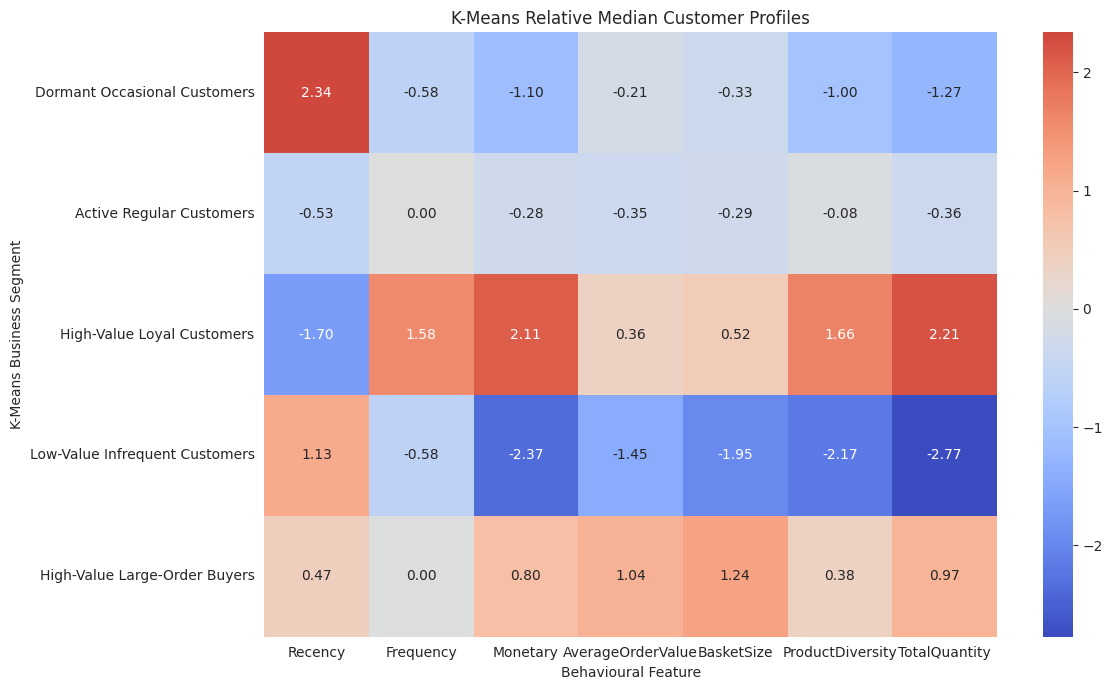

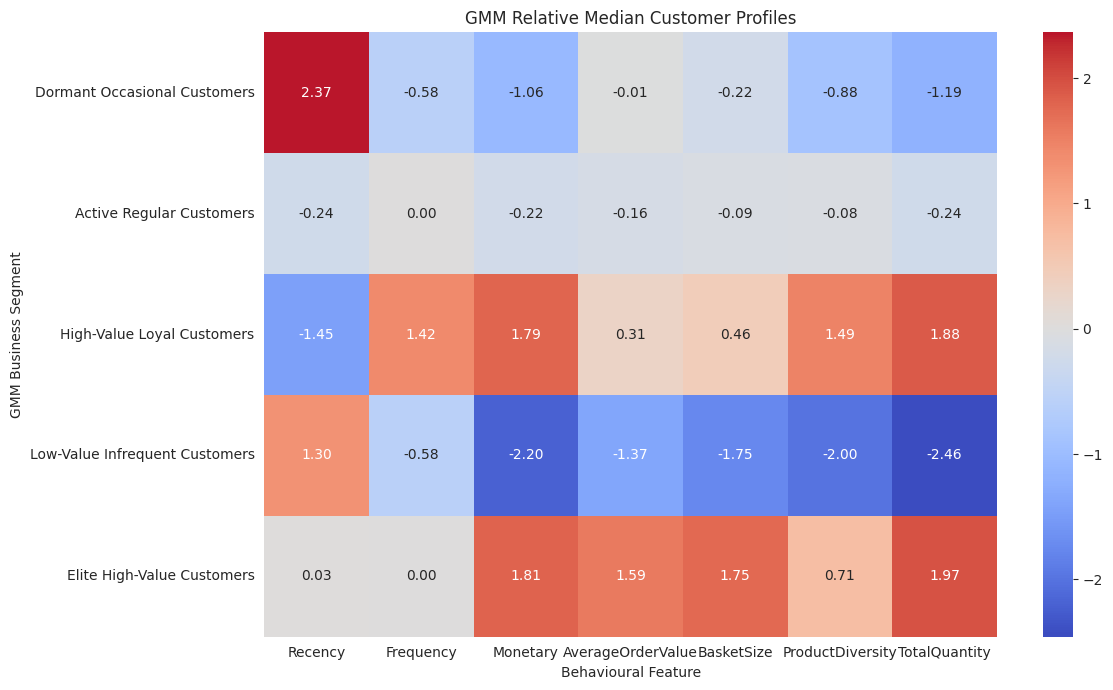

In [ ]:
kmeans_heatmap = (
    kmeans_median_signature
    .set_index(
        "Segment_Name"
    )[
        FEATURE_COLUMNS
    ]
)

gmm_heatmap = (
    gmm_median_signature
    .set_index(
        "GMM_Segment_Name"
    )[
        FEATURE_COLUMNS
    ]
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    kmeans_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "K-Means Relative Median Customer Profiles"
)
plt.xlabel("Behavioural Feature")
plt.ylabel("K-Means Business Segment")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "kmeans_relative_median_profile_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(12, 7))

sns.heatmap(
    gmm_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "GMM Relative Median Customer Profiles"
)
plt.xlabel("Behavioural Feature")
plt.ylabel("GMM Business Segment")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "gmm_relative_median_profile_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

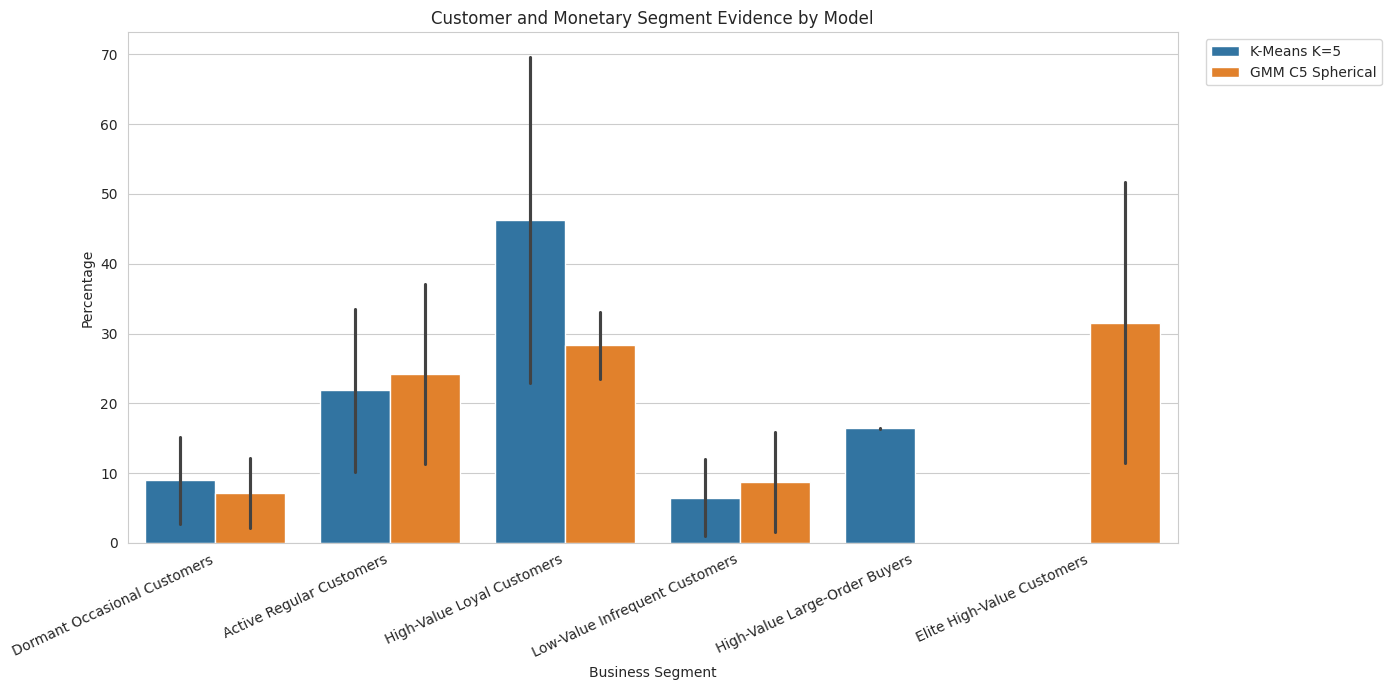

In [ ]:
segment_share_plot = (
    combined_segment_summary[
        [
            "Model",
            "Business_Segment",
            "Customer_Percentage",
            "Monetary_Contribution_Percentage"
        ]
    ]
    .melt(
        id_vars=[
            "Model",
            "Business_Segment"
        ],
        var_name="Share_Type",
        value_name="Percentage"
    )
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=segment_share_plot,
    x="Business_Segment",
    y="Percentage",
    hue="Model"
)

plt.title(
    "Customer and Monetary Segment Evidence by Model"
)
plt.xlabel("Business Segment")
plt.ylabel("Percentage")
plt.xticks(
    rotation=25,
    ha="right"
)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "combined_segment_share_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

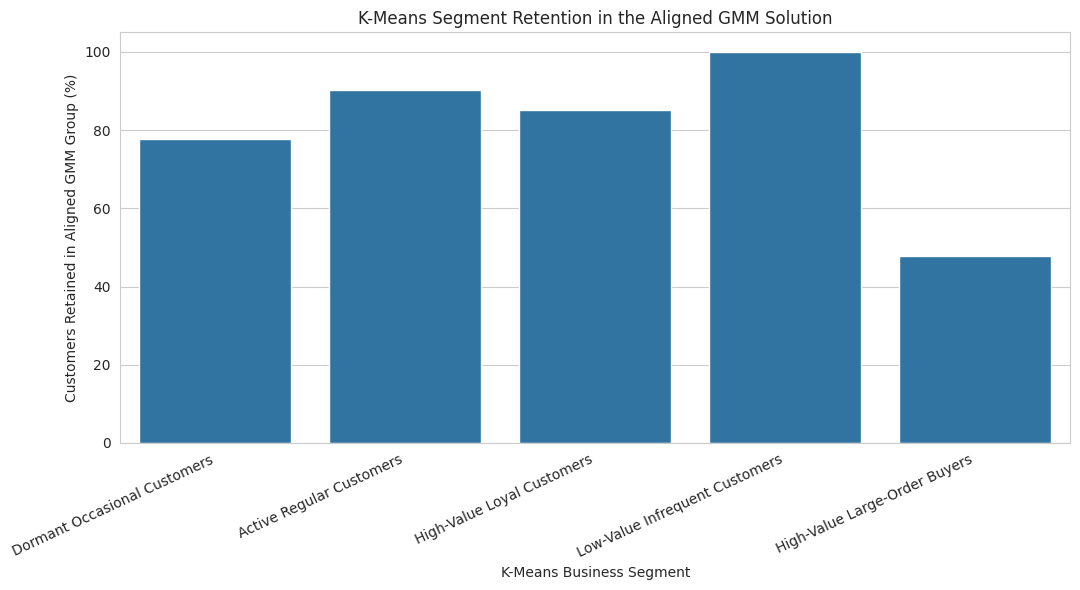

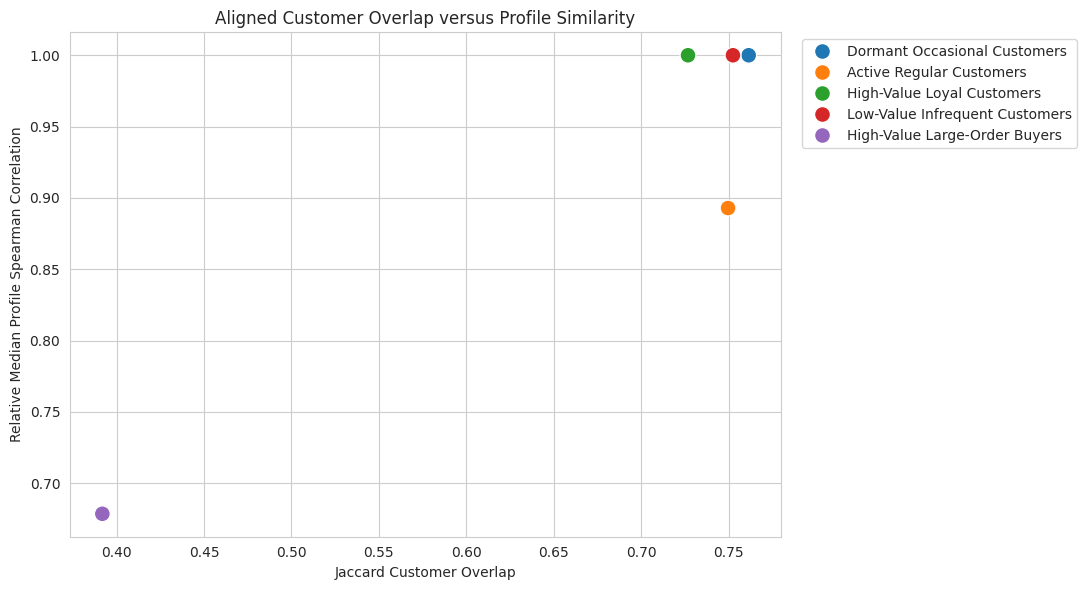

In [ ]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=aligned_profile_evidence,
    x="KMeans_Segment",
    y="KMeans_Retention_Percentage"
)

plt.title(
    "K-Means Segment Retention in the Aligned GMM Solution"
)
plt.xlabel("K-Means Business Segment")
plt.ylabel("Customers Retained in Aligned GMM Group (%)")
plt.xticks(
    rotation=25,
    ha="right"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "aligned_segment_customer_retention.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=aligned_profile_evidence,
    x="Jaccard_Overlap",
    y="Relative_Median_Profile_Spearman",
    hue="KMeans_Segment",
    s=130
)

plt.title(
    "Aligned Customer Overlap versus Profile Similarity"
)
plt.xlabel("Jaccard Customer Overlap")
plt.ylabel("Relative Median Profile Spearman Correlation")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "aligned_overlap_vs_profile_similarity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 15. Build the final multi-criteria evidence table

The final recommendation distinguishes:

- technical separation;
- stability;
- operational feasibility;
- assignment agreement;
- interpretability;
- uncertainty support;
- model simplicity.

The table records evidence and trade-offs rather than counting equal-weight
metric wins.

In [ ]:
technical_lookup = (
    technical_metrics
    .set_index(
        "Metric"
    )
)

assignment_ari = float(
    assignment_agreement.loc[
        assignment_agreement[
            "Agreement_Measure"
        ] == "Adjusted Rand Index",
        "Value"
    ].iloc[0]
)

assignment_nmi = float(
    assignment_agreement.loc[
        assignment_agreement[
            "Agreement_Measure"
        ] == "Normalised Mutual Information",
        "Value"
    ].iloc[0]
)

aligned_exact_agreement = float(
    customer_data[
        "Models_Agree_After_Alignment"
    ].mean()
)

kmeans_negative_silhouette_percentage = float(
    (
        customer_data[
            "Silhouette_Value_KMeans"
        ] < 0
    ).mean()
    * 100
)

gmm_negative_silhouette_percentage = float(
    (
        customer_data[
            "Silhouette_Value_GMM"
        ] < 0
    ).mean()
    * 100
)

kmeans_boundary_percentage = float(
    customer_data[
        "Combined_Boundary_Flag"
    ].mean()
    * 100
)

gmm_ambiguous_percentage = float(
    customer_data[
        "Combined_Ambiguous_Flag"
    ].mean()
    * 100
)

final_evidence_rows = [
    {
        "Criterion": "Common internal validation",
        "KMeans_Evidence": (
            "Higher Silhouette and CH; lower DBI."
        ),
        "GMM_Evidence": (
            "Acceptable but weaker on all three "
            "common internal metrics."
        ),
        "Evidence_Preference": "K-Means K=5",
        "Decision_Weight": "High"
    },
    {
        "Criterion": "Random-seed stability",
        "KMeans_Evidence": (
            "Mean ARI "
            f"{technical_lookup.loc['Mean Random-Seed ARI', 'KMeans_K5']:.4f}; "
            "minimum "
            f"{technical_lookup.loc['Minimum Random-Seed ARI', 'KMeans_K5']:.4f}."
        ),
        "GMM_Evidence": (
            "Mean ARI "
            f"{technical_lookup.loc['Mean Random-Seed ARI', 'GMM_C5_Spherical']:.4f}; "
            "minimum "
            f"{technical_lookup.loc['Minimum Random-Seed ARI', 'GMM_C5_Spherical']:.4f}."
        ),
        "Evidence_Preference": "K-Means K=5",
        "Decision_Weight": "High"
    },
    {
        "Criterion": "Subsampling stability",
        "KMeans_Evidence": (
            "Mean ARI "
            f"{technical_lookup.loc['Mean 80% Subsampling ARI', 'KMeans_K5']:.4f}; "
            "minimum "
            f"{technical_lookup.loc['Minimum 80% Subsampling ARI', 'KMeans_K5']:.4f}."
        ),
        "GMM_Evidence": (
            "Mean ARI "
            f"{technical_lookup.loc['Mean 80% Subsampling ARI', 'GMM_C5_Spherical']:.4f}; "
            "minimum "
            f"{technical_lookup.loc['Minimum 80% Subsampling ARI', 'GMM_C5_Spherical']:.4f}."
        ),
        "Evidence_Preference": (
            "Both strong; GMM higher mean, K-Means stronger minimum"
        ),
        "Decision_Weight": "High"
    },
    {
        "Criterion": "Group-size feasibility",
        "KMeans_Evidence": (
            "Smallest group "
            f"{technical_lookup.loc['Smallest Group Percentage', 'KMeans_K5']:.2f}%."
        ),
        "GMM_Evidence": (
            "Smallest group "
            f"{technical_lookup.loc['Smallest Group Percentage', 'GMM_C5_Spherical']:.2f}%."
        ),
        "Evidence_Preference": "Both feasible",
        "Decision_Weight": "Required gate"
    },
    {
        "Criterion": "Cross-model structural agreement",
        "KMeans_Evidence": (
            f"ARI={assignment_ari:.4f}, "
            f"NMI={assignment_nmi:.4f}, "
            f"aligned agreement={aligned_exact_agreement * 100:.2f}%."
        ),
        "GMM_Evidence": (
            "Substantial common structure with "
            "meaningful differences in high-value customers."
        ),
        "Evidence_Preference": "Complementary evidence",
        "Decision_Weight": "Contextual"
    },
    {
        "Criterion": "Geometric boundary evidence",
        "KMeans_Evidence": (
            f"Negative Silhouette: "
            f"{kmeans_negative_silhouette_percentage:.2f}%."
        ),
        "GMM_Evidence": (
            f"Negative Silhouette: "
            f"{gmm_negative_silhouette_percentage:.2f}%."
        ),
        "Evidence_Preference": "K-Means K=5",
        "Decision_Weight": "Medium"
    },
    {
        "Criterion": "Customer-level uncertainty capability",
        "KMeans_Evidence": (
            f"Centroid and Silhouette review group: "
            f"{kmeans_boundary_percentage:.2f}%."
        ),
        "GMM_Evidence": (
            f"Probability-based ambiguous group: "
            f"{gmm_ambiguous_percentage:.2f}%; "
            "also provides full posterior probabilities."
        ),
        "Evidence_Preference": "GMM C5 Spherical",
        "Decision_Weight": "Supporting"
    },
    {
        "Criterion": "Business interpretability",
        "KMeans_Evidence": (
            "Five established and directly explainable "
            "customer profiles."
        ),
        "GMM_Evidence": (
            "Four close analogues plus an informative "
            "elite high-value component."
        ),
        "Evidence_Preference": (
            "K-Means primary; GMM adds refinement"
        ),
        "Decision_Weight": "High"
    },
    {
        "Criterion": "Operational simplicity",
        "KMeans_Evidence": (
            "Nearest-centroid assignment is simple to "
            "explain, reproduce and deploy."
        ),
        "GMM_Evidence": (
            "Probability model provides richer evidence "
            "but requires more explanation."
        ),
        "Evidence_Preference": "K-Means K=5",
        "Decision_Weight": "Medium"
    }
]

final_evidence_table = pd.DataFrame(
    final_evidence_rows
)

display(final_evidence_table)

final_evidence_table.to_csv(
    DECISION_DIR
    / "final_multi_criteria_model_evidence.csv",
    index=False
)

,Criterion,KMeans_Evidence,GMM_Evidence,Evidence_Preference,Decision_Weight
0,Common internal validation,Higher Silhouette and CH; lower DBI.,Acceptable but weaker on all three common inte...,K-Means K=5,High
1,Random-seed stability,Mean ARI 0.9999; minimum 0.9996.,Mean ARI 0.9985; minimum 0.9918.,K-Means K=5,High
2,Subsampling stability,Mean ARI 0.9541; minimum 0.9011.,Mean ARI 0.9610; minimum 0.8898.,"Both strong; GMM higher mean, K-Means stronger...",High
3,Group-size feasibility,Smallest group 11.99%.,Smallest group 11.39%.,Both feasible,Required gate
4,Cross-model structural agreement,"ARI=0.6289, NMI=0.6512, aligned agreement=81.40%.",Substantial common structure with meaningful d...,Complementary evidence,Contextual
5,Geometric boundary evidence,Negative Silhouette: 4.73%.,Negative Silhouette: 14.48%.,K-Means K=5,Medium
6,Customer-level uncertainty capability,Centroid and Silhouette review group: 12.47%.,Probability-based ambiguous group: 5.97%; also...,GMM C5 Spherical,Supporting
7,Business interpretability,Five established and directly explainable cust...,Four close analogues plus an informative elite...,K-Means primary; GMM adds refinement,High
8,Operational simplicity,Nearest-centroid assignment is simple to expla...,Probability model provides richer evidence but...,K-Means K=5,Medium


## 16. Record the final operational-model decision

### Primary model

K-Means K=5 is retained as the primary operational segmentation because it:

- performs better on all three common internal validation metrics;
- has near-perfect random-seed stability;
- has a stronger worst-case subsampling result;
- creates five practical, established and directly actionable customer groups;
- is simpler to explain and reproduce.

### Supporting model

GMM C5 spherical is retained as a comparative and uncertainty-analysis layer
because it:

- demonstrates that the main customer structure is largely reproduced;
- provides posterior membership probabilities;
- identifies alternative components and customer overlap;
- reveals a concentrated `Elite High-Value Customers` group;
- provides additional evidence around customers near behavioural boundaries.

The GMM result adds analytical value without replacing the more transparent
K-Means operational segmentation.

In [ ]:
final_model_decision = {
    "primary_operational_model": {
        "model": "K-Means K=5",
        "status": "Selected",
        "reasons": [
            (
                "Stronger Silhouette, Davies-Bouldin and "
                "Calinski-Harabasz results."
            ),
            (
                "Near-perfect random-seed stability and "
                "strong worst-case subsampling stability."
            ),
            (
                "Five practical and directly actionable "
                "business profiles."
            ),
            (
                "Simpler assignment logic and stronger "
                "operational transparency."
            )
        ]
    },
    "supporting_comparative_model": {
        "model": "GMM C5 Spherical",
        "status": (
            "Retained as probabilistic comparison "
            "and customer-confidence layer"
        ),
        "contributions": [
            (
                "Posterior probabilities for all five components."
            ),
            (
                "Alternative-component and entropy evidence."
            ),
            (
                "Substantial reproduction of the main "
                "five-group customer structure."
            ),
            (
                "Identification of a concentrated elite "
                "high-value customer group."
            )
        ]
    },
    "cross_model_evidence": {
        "adjusted_rand_index": (
            assignment_ari
        ),
        "normalised_mutual_information": (
            assignment_nmi
        ),
        "exact_agreement_after_alignment": (
            aligned_exact_agreement
        )
    },
    "important_limitation": (
        "The final recommendation is based on internal "
        "validation, stability and business interpretation. "
        "No ground-truth customer segment labels or campaign "
        "outcome experiment is available."
    ),
    "dashboard_recommendation": (
        "Use K-Means segment as the primary business segment. "
        "Display GMM component, maximum probability, alternative "
        "component and confidence status as a supporting layer."
    )
}

with open(
    DECISION_DIR
    / "final_operational_model_decision.json",
    "w"
) as file:
    json.dump(
        final_model_decision,
        file,
        indent=4
    )

print(
    json.dumps(
        final_model_decision,
        indent=4
    )
)

{
    "primary_operational_model": {
        "model": "K-Means K=5",
        "status": "Selected",
        "reasons": [
            "Stronger Silhouette, Davies-Bouldin and Calinski-Harabasz results.",
            "Near-perfect random-seed stability and strong worst-case subsampling stability.",
            "Five practical and directly actionable business profiles.",
            "Simpler assignment logic and stronger operational transparency."
        ]
    },
    "supporting_comparative_model": {
        "model": "GMM C5 Spherical",
        "status": "Retained as probabilistic comparison and customer-confidence layer",
        "contributions": [
            "Posterior probabilities for all five components.",
            "Alternative-component and entropy evidence.",
            "Substantial reproduction of the main five-group customer structure.",
            "Identification of a concentrated elite high-value customer group."
        ]
    },
    "cross_model_evidence": {
        "adj

## 17. Create the final dashboard-ready customer table

The dashboard table contains:

- original customer behavioural features;
- primary K-Means business segment;
- K-Means confidence evidence;
- supporting GMM business segment;
- GMM probability evidence;
- aligned model agreement;
- cross-model uncertainty status;
- primary strategy and KPI.

In [ ]:
primary_strategy_columns = (
    business_strategy_mapping[
        business_strategy_mapping[
            "Model"
        ] == "K-Means K=5"
    ][
        [
            "Group_Number",
            "Primary_Objective",
            "Recommended_Action",
            "Primary_KPI",
            "Operational_Priority"
        ]
    ]
    .rename(
        columns={
            "Group_Number": "Cluster"
        }
    )
)

dashboard_customer_data = (
    customer_data
    .merge(
        primary_strategy_columns,
        on="Cluster",
        how="left",
        validate="many_to_one"
    )
)

dashboard_customer_data[
    "Primary_Operational_Model"
] = "K-Means K=5"

dashboard_customer_data[
    "Supporting_Analytical_Model"
] = "GMM C5 Spherical"

dashboard_customer_data.to_csv(
    DATASETS_DIR
    / "final_customer_segmentation_dashboard_data.csv",
    index=False
)

combined_segment_summary.to_csv(
    DATASETS_DIR
    / "final_dashboard_segment_summary.csv",
    index=False
)

business_strategy_mapping.to_csv(
    DATASETS_DIR
    / "final_dashboard_strategy_mapping.csv",
    index=False
)

technical_metrics.to_csv(
    DATASETS_DIR
    / "final_dashboard_model_metrics.csv",
    index=False
)

print(
    "Final dashboard datasets exported."
)

Final dashboard datasets exported.


## 18. Run final profile and decision quality checks

In [ ]:
assert len(
    dashboard_customer_data
) == EXPECTED_CUSTOMERS

assert dashboard_customer_data[
    "CustomerID"
].is_unique

assert dashboard_customer_data[
    "Segment_Name"
].notna().all()

assert dashboard_customer_data[
    "GMM_Segment_Name"
].notna().all()

assert set(
    dashboard_customer_data[
        "GMM_Segment_Name"
    ].unique()
) == set(
    GMM_NAME_BY_ALIGNED_CLUSTER.values()
)

assert np.isclose(
    kmeans_profiles[
        "summary"
    ][
        "Customer_Percentage"
    ].sum(),
    100
)

assert np.isclose(
    gmm_profiles[
        "summary"
    ][
        "Customer_Percentage"
    ].sum(),
    100
)

assert np.isclose(
    kmeans_profiles[
        "summary"
    ][
        "Monetary_Contribution_Percentage"
    ].sum(),
    100
)

assert np.isclose(
    gmm_profiles[
        "summary"
    ][
        "Monetary_Contribution_Percentage"
    ].sum(),
    100
)

assert len(
    aligned_profile_evidence
) == EXPECTED_GROUPS

assert len(
    business_strategy_mapping
) == EXPECTED_GROUPS * 2

required_outputs = [
    TABLES_DIR
    / "final_gmm_component_business_name_mapping.csv",
    TABLES_DIR
    / "combined_model_segment_summary.csv",
    TABLES_DIR
    / "aligned_group_profile_and_overlap_evidence.csv",
    TABLES_DIR
    / "segment_top_defining_features.csv",
    TABLES_DIR
    / "model_profile_distinctiveness_summary.csv",
    STRATEGY_DIR
    / "model_segment_business_strategy_mapping.csv",
    DECISION_DIR
    / "final_multi_criteria_model_evidence.csv",
    DECISION_DIR
    / "final_operational_model_decision.json",
    DATASETS_DIR
    / "final_customer_segmentation_dashboard_data.csv",
    DATASETS_DIR
    / "final_dashboard_segment_summary.csv",
    DATASETS_DIR
    / "final_dashboard_strategy_mapping.csv",
    DATASETS_DIR
    / "final_dashboard_model_metrics.csv"
]

missing_outputs = [
    str(path)
    for path in required_outputs
    if not path.exists()
]

if missing_outputs:
    raise FileNotFoundError(
        "Missing required Step 8 outputs:\n"
        + "\n".join(
            missing_outputs
        )
    )

quality_checks = pd.DataFrame({
    "Quality_Check": [
        "Dashboard customer count remains 4,338",
        "CustomerID values remain unique",
        "All K-Means segment names complete",
        "All GMM segment names complete",
        "Five expected GMM names present",
        "K-Means customer percentages total 100",
        "GMM customer percentages total 100",
        "K-Means monetary shares total 100",
        "GMM monetary shares total 100",
        "Five aligned profile comparisons created",
        "Ten model-strategy rows created",
        "Required Step 8 outputs created"
    ],
    "Passed": [
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True
    ]
})

display(quality_checks)

quality_checks.to_csv(
    QUALITY_DIR
    / "profile_alignment_and_final_decision_quality_checks.csv",
    index=False
)

print(
    "All Step 8 quality checks passed."
)

,Quality_Check,Passed
0,"Dashboard customer count remains 4,338",True
1,CustomerID values remain unique,True
2,All K-Means segment names complete,True
3,All GMM segment names complete,True
4,Five expected GMM names present,True
5,K-Means customer percentages total 100,True
6,GMM customer percentages total 100,True
7,K-Means monetary shares total 100,True
8,GMM monetary shares total 100,True
9,Five aligned profile comparisons created,True


All Step 8 quality checks passed.


## 19. Create the supervisor-ready final comparison summary

In [ ]:
technical_metric_lookup = (
    technical_metrics
    .set_index(
        "Metric"
    )
)

largest_difference_row = (
    aligned_profile_evidence
    .sort_values(
        "KMeans_Retention_Percentage"
    )
    .iloc[0]
)

supervisor_summary = f'''
FINAL K-MEANS AND GMM PROFILE INTERPRETATION

Analytical population
---------------------
Customers: {EXPECTED_CUSTOMERS:,}
Features: {len(FEATURE_COLUMNS)}
Groups per model: {EXPECTED_GROUPS}

Technical comparison
--------------------
K-Means Silhouette:
{technical_metric_lookup.loc["Silhouette Score", "KMeans_K5"]:.4f}

GMM Silhouette:
{technical_metric_lookup.loc["Silhouette Score", "GMM_C5_Spherical"]:.4f}

K-Means Davies-Bouldin:
{technical_metric_lookup.loc["Davies-Bouldin Index", "KMeans_K5"]:.4f}

GMM Davies-Bouldin:
{technical_metric_lookup.loc["Davies-Bouldin Index", "GMM_C5_Spherical"]:.4f}

K-Means Calinski-Harabasz:
{technical_metric_lookup.loc["Calinski-Harabasz Index", "KMeans_K5"]:.2f}

GMM Calinski-Harabasz:
{technical_metric_lookup.loc["Calinski-Harabasz Index", "GMM_C5_Spherical"]:.2f}

Cross-model agreement
---------------------
Adjusted Rand Index:
{assignment_ari:.4f}

Normalised Mutual Information:
{assignment_nmi:.4f}

Exact agreement after alignment:
{aligned_exact_agreement * 100:.2f}%

Profile interpretation
----------------------
Four GMM groups retained business interpretations closely related
to the corresponding K-Means groups.

The fifth GMM group was named Elite High-Value Customers because
it combined very high Monetary value, Average Order Value,
Basket Size, Total Quantity and strong purchase Frequency.

Largest aligned difference
--------------------------
K-Means segment:
{largest_difference_row["KMeans_Segment"]}

Aligned GMM segment:
{largest_difference_row["GMM_Segment"]}

K-Means customers retained in the aligned GMM group:
{largest_difference_row["KMeans_Retention_Percentage"]:.2f}%

Final operational decision
--------------------------
Primary segmentation:
K-Means K=5

Supporting comparative and confidence model:
GMM C5 spherical

Rationale
---------
K-Means achieved stronger common internal validation, near-perfect
random-seed stability, a stronger worst-case subsampling result and
five directly actionable customer profiles.

GMM retained substantial common structure and added posterior
membership probabilities, alternative-component evidence and an
elite high-value refinement.

The dashboard should therefore use the K-Means segment as the
primary business group and display GMM membership evidence as a
supporting analytical layer.
'''.strip()

with open(
    RESULTS_DIR
    / "supervisor_final_model_decision_summary.txt",
    "w"
) as file:
    file.write(
        supervisor_summary
    )

print(supervisor_summary)

FINAL K-MEANS AND GMM PROFILE INTERPRETATION

Analytical population
---------------------
Customers: 4,338
Features: 7
Groups per model: 5

Technical comparison
--------------------
K-Means Silhouette:
0.2512

GMM Silhouette:
0.2299

K-Means Davies-Bouldin:
1.2230

GMM Davies-Bouldin:
1.3749

K-Means Calinski-Harabasz:
1755.97

GMM Calinski-Harabasz:
1587.50

Cross-model agreement
---------------------
Adjusted Rand Index:
0.6289

Normalised Mutual Information:
0.6512

Exact agreement after alignment:
81.40%

Profile interpretation
----------------------
Four GMM groups retained business interpretations closely related
to the corresponding K-Means groups.

The fifth GMM group was named Elite High-Value Customers because
it combined very high Monetary value, Average Order Value,
Basket Size, Total Quantity and strong purchase Frequency.

Largest aligned difference
--------------------------
K-Means segment:
High-Value Large-Order Buyers

Aligned GMM segment:
Elite High-Value Customers



In [ ]:
step8_manifest = {
    "purpose": (
        "Align and interpret frozen K-Means K=5 and "
        "GMM C5 spherical customer profiles."
    ),
    "models_retrained": False,
    "customers": EXPECTED_CUSTOMERS,
    "features": FEATURE_COLUMNS,
    "alignment": {
        "source": (
            "Step 7 Hungarian maximum-overlap mapping"
        ),
        "limitation": (
            "Customer overlap does not alone establish "
            "identical business meaning."
        )
    },
    "gmm_business_names": (
        GMM_NAME_BY_ALIGNED_CLUSTER
    ),
    "profile_comparison": {
        "statistics": [
            "mean",
            "median",
            "first quartile",
            "third quartile",
            "customer share",
            "monetary contribution"
        ],
        "relative_signature": (
            "Log2 ratio of group statistic plus one "
            "to overall statistic plus one."
        )
    },
    "final_decision": {
        "primary_operational_model": (
            "K-Means K=5"
        ),
        "supporting_model": (
            "GMM C5 Spherical"
        )
    },
    "dashboard_design": (
        "K-Means primary segment with GMM membership, "
        "probability and uncertainty as supporting fields."
    ),
    "important_limitations": [
        (
            "No ground-truth customer labels are available."
        ),
        (
            "Business strategies are analytical recommendations "
            "rather than experimentally validated outcomes."
        ),
        (
            "GMM posterior probabilities depend on the fitted "
            "mixture-model assumptions."
        )
    ]
}

with open(
    RESULTS_DIR
    / "step8_profile_interpretation_manifest.json",
    "w"
) as file:
    json.dump(
        step8_manifest,
        file,
        indent=4
    )

print(
    " methodology manifest saved."
)

Step 8 methodology manifest saved.


In [ ]:
zip_path = shutil.make_archive(
    base_name=(
        "/content/"
        "Profile_Alignment_and_Final_Model_Decision_Results"
    ),
    format="zip",
    root_dir=RESULTS_DIR
)

print("=" * 80)
print("STEP COMPLETED")
print("=" * 80)

print("\nResults folder:")
print(RESULTS_DIR)

print("\nZIP archive:")
print(zip_path)

print("\nKey outputs:")
print("1. final_gmm_component_business_name_mapping.csv")
print("2. combined_model_segment_summary.csv")
print("3. aligned_group_profile_and_overlap_evidence.csv")
print("4. segment_top_defining_features.csv")
print("5. model_profile_distinctiveness_summary.csv")
print("6. high_value_customer_redistribution.csv")
print("7. model_segment_business_strategy_mapping.csv")
print("8. final_multi_criteria_model_evidence.csv")
print("9. final_operational_model_decision.json")
print("10. final_customer_segmentation_dashboard_data.csv")
print("11. supervisor_final_model_decision_summary.txt")

STEP 8 COMPLETED

Results folder:
/content/Profile_Alignment_and_Final_Model_Decision_Results

ZIP archive:
/content/Profile_Alignment_and_Final_Model_Decision_Results.zip

Key outputs:
1. final_gmm_component_business_name_mapping.csv
2. combined_model_segment_summary.csv
3. aligned_group_profile_and_overlap_evidence.csv
4. segment_top_defining_features.csv
5. model_profile_distinctiveness_summary.csv
6. high_value_customer_redistribution.csv
7. model_segment_business_strategy_mapping.csv
8. final_multi_criteria_model_evidence.csv
9. final_operational_model_decision.json
10. final_customer_segmentation_dashboard_data.csv
11. supervisor_final_model_decision_summary.txt


## Final dissertation conclusion

The two algorithms reproduced a substantial common customer structure, but
they were not identical.

K-Means is retained as the primary operational model because it provides the
stronger combination of:

- common validation;
- stability;
- transparency;
- direct business interpretation.

GMM is retained as a supporting probabilistic model because it adds:

- soft membership;
- alternative component evidence;
- uncertainty analysis;
- a refined elite high-value customer group.